# Kaggle API credentials configured securely
# Dataset downloaded using Kaggle API

In [ ]:
!ls "plantvillage dataset"

color  grayscale  segmented


In [ ]:
!ls "plantvillage dataset/color" | head

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___healthy
Cherry_(including_sour)___Powdery_mildew
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___healthy


In [ ]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)


In [ ]:
import os
import json
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


In [ ]:
base_dir = "/content/plantvillage dataset/color"

Plant Classes

In [ ]:
import os

if os.path.isdir(base_dir):
    classes = os.listdir(base_dir)
    print("Number of Classes =", len(classes))
    print(classes[:10])
else:
    print(f"Error: The directory '{base_dir}' was not found.")
    print("This often happens if the dataset was not downloaded and unzipped correctly, or if the runtime was restarted.")
    print("Please ensure you have run the cells to download and unzip the dataset (e.g., `!kaggle datasets download ...` and `!unzip ...`).")
    classes = [] # Initialize classes as an empty list to avoid further errors in subsequent operations if this cell is not fixed.

Number of Classes = 38
['Cherry_(including_sour)___Powdery_mildew', 'Apple___Apple_scab', 'Corn_(maize)___healthy', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Early_blight', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Squash___Powdery_mildew']


In [ ]:
# Extract plant names (before ___)
plants = set([cls.split('___')[0] for cls in classes])

print("Number of Plant Types:", len(plants))
print("Plant Types:", plants)

Number of Plant Types: 14
Plant Types: {'Orange', 'Pepper,_bell', 'Tomato', 'Corn_(maize)', 'Squash', 'Soybean', 'Potato', 'Grape', 'Strawberry', 'Cherry_(including_sour)', 'Peach', 'Blueberry', 'Raspberry', 'Apple'}


In [ ]:
img_size = 224
batch_size = 32


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False

)


Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)


Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 96s 66ms/step - accuracy: 0.7435 - loss: 0.9078 - val_accuracy: 0.8697 - val_loss: 0.4156
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 97s 72ms/step - accuracy: 0.9185 - loss: 0.2526 - val_accuracy: 0.8699 - val_loss: 0.4043
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 91s 67ms/step - accuracy: 0.9628 - loss: 0.1130 - val_accuracy: 0.8833 - val_loss: 0.4273
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 89s 66ms/step - accuracy: 0.9753 - loss: 0.0743 - val_accuracy: 0.8955 - val_loss: 0.4495
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 90s 66ms/step - accuracy: 0.9806 - loss: 0.0598 - val_accuracy: 0.8834 - val_loss: 0.5210


Model Evaluation

In [ ]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(
    validation_generator,
    steps=validation_generator.samples // batch_size
)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.8834 - loss: 0.5210
Validation Accuracy: 88.34%


Plot Accuracy & Loss Curves

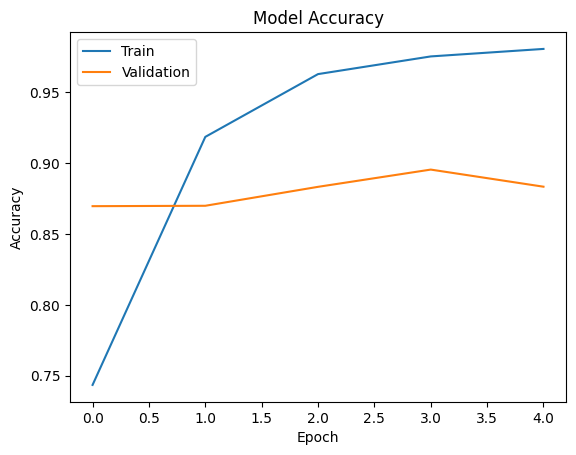

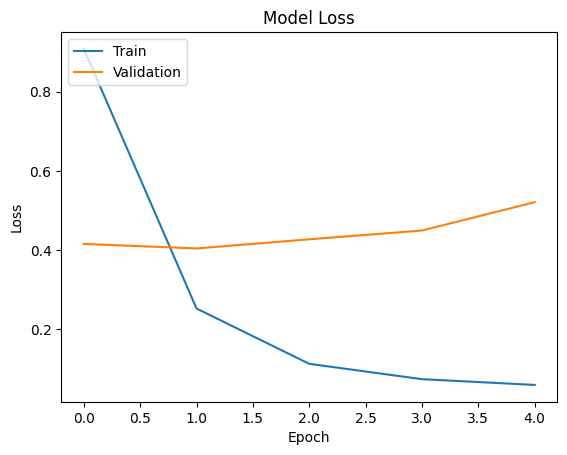

In [ ]:
# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


Image Preprocessing Function

In [ ]:
from PIL import Image
import numpy as np

def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array.astype('float32') / 255.0
    return img_array


Prediction Function

In [ ]:
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name


Create Class Index Mapping

In [ ]:
# Create mapping from index to class name
class_indices = {v: k for k, v in train_generator.class_indices.items()}

Save Class Indices

In [ ]:
import json
json.dump(class_indices, open('class_indices.json', 'w'))


Test the Predictive System

In [ ]:
import os

# Define the directory for Potato___Late_blight within the dataset
potato_lateblight_dir = os.path.join(base_dir, 'Potato___Late_blight')

# Get a list of all files in that directory
image_files = os.listdir(potato_lateblight_dir)

# Select the first image file for testing (ensure there's at least one file)
if image_files:
    image_path = os.path.join(potato_lateblight_dir, image_files[0])
else:
    print(f"No images found in {potato_lateblight_dir}")
    image_path = None # Set to None or handle appropriately


if image_path:
    predicted_class_name = predict_image_class(
        model,
        image_path,
        class_indices
    )

    print("Predicted Class Name:", predicted_class_name)
else:
    print("Could not perform prediction as no image path was found.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class Name: Potato___Late_blight


Save Model Locally

In [ ]:
model.save('plant_disease_prediction_model.h5')


In [ ]:
model.save("plant_disease_prediction_model.keras")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/PlantDiseaseModel


In [ ]:
!cp plant_disease_prediction_model.keras /content/drive/MyDrive/PlantDiseaseModel/
!cp class_indices.json /content/drive/MyDrive/PlantDiseaseModel/


In [ ]:
!ls /content/drive/MyDrive/PlantDiseaseModel


class_indices.json  plant_disease_prediction_model.keras


In [ ]:
y_true = validation_generator.classes

y_pred_probs = model.predict(validation_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

340/340 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step


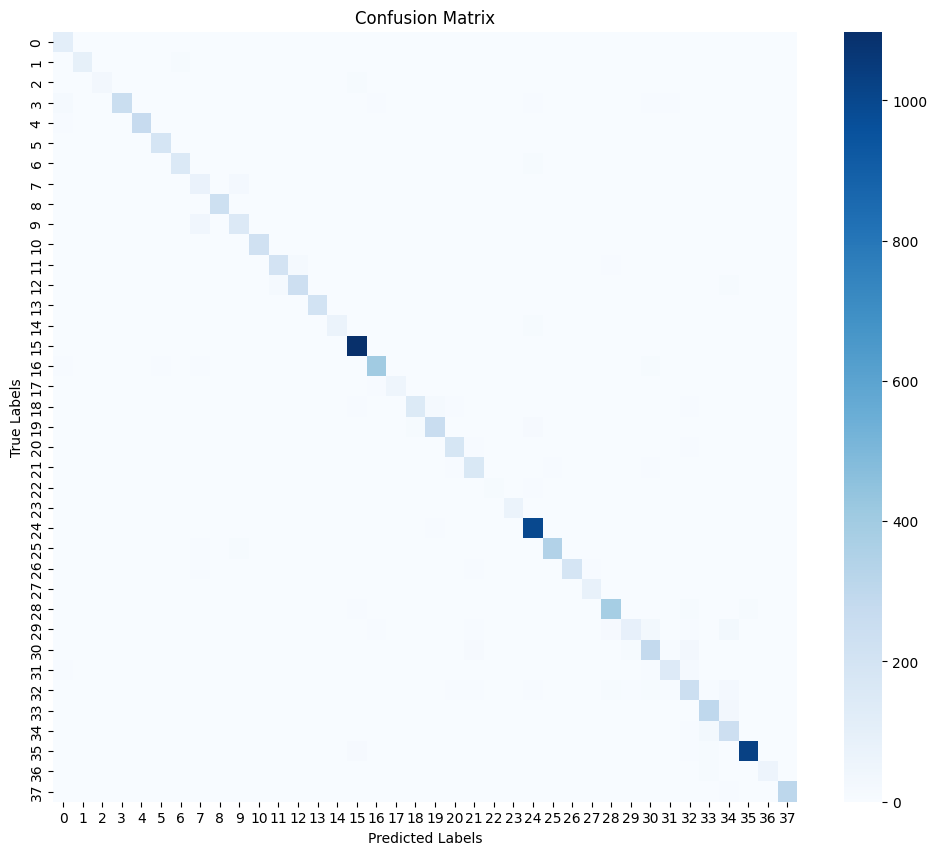

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [
        round(0.8785, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4)
    ]
})

print(metrics_df)

      Metric   Value
0   Accuracy  0.8785
1  Precision  0.8884
2     Recall  0.8834
3   F1-Score  0.8831


In [ ]:
from tensorflow.keras.metrics import TopKCategoricalAccuracy
import tensorflow as tf

top5 = TopKCategoricalAccuracy(k=5)

# Convert y_true to one-hot encoded format
num_classes = train_generator.num_classes
y_true_one_hot = tf.one_hot(y_true, depth=num_classes)

top5.update_state(y_true_one_hot, y_pred_probs)

print("Top-5 Accuracy:", top5.result().numpy())

Top-5 Accuracy: 0.99133563


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


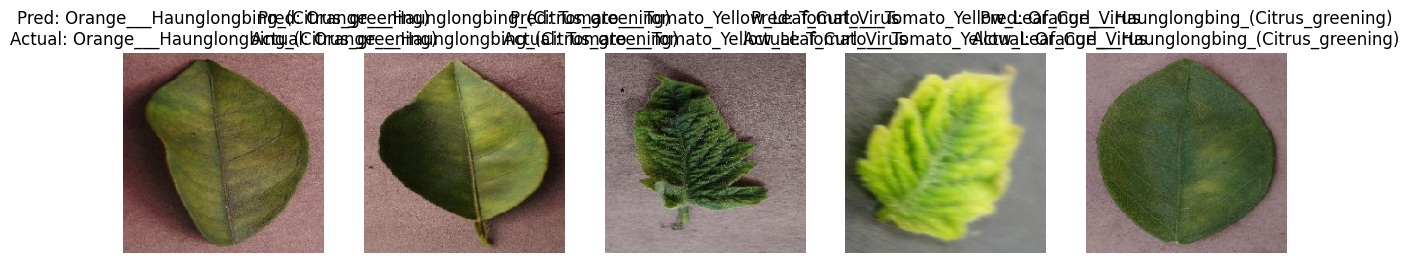

In [ ]:
import random
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Get class labels mapping
class_labels = list(train_generator.class_indices.keys())

# Function to display predictions
def show_predictions(generator, model, num_images=5):
    plt.figure(figsize=(15,5))

    for i in range(num_images):
        idx = random.randint(0, len(generator.filepaths)-1)
        img_path = generator.filepaths[idx]

        img = load_img(img_path, target_size=(224,224))
        img_array = img_to_array(img)/255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array)
        pred_class = class_labels[np.argmax(pred)]
        true_class = img_path.split('/')[-2]

        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(f"Pred: {pred_class}\nActual: {true_class}")
        plt.axis('off')

    plt.show()

show_predictions(validation_generator, model)

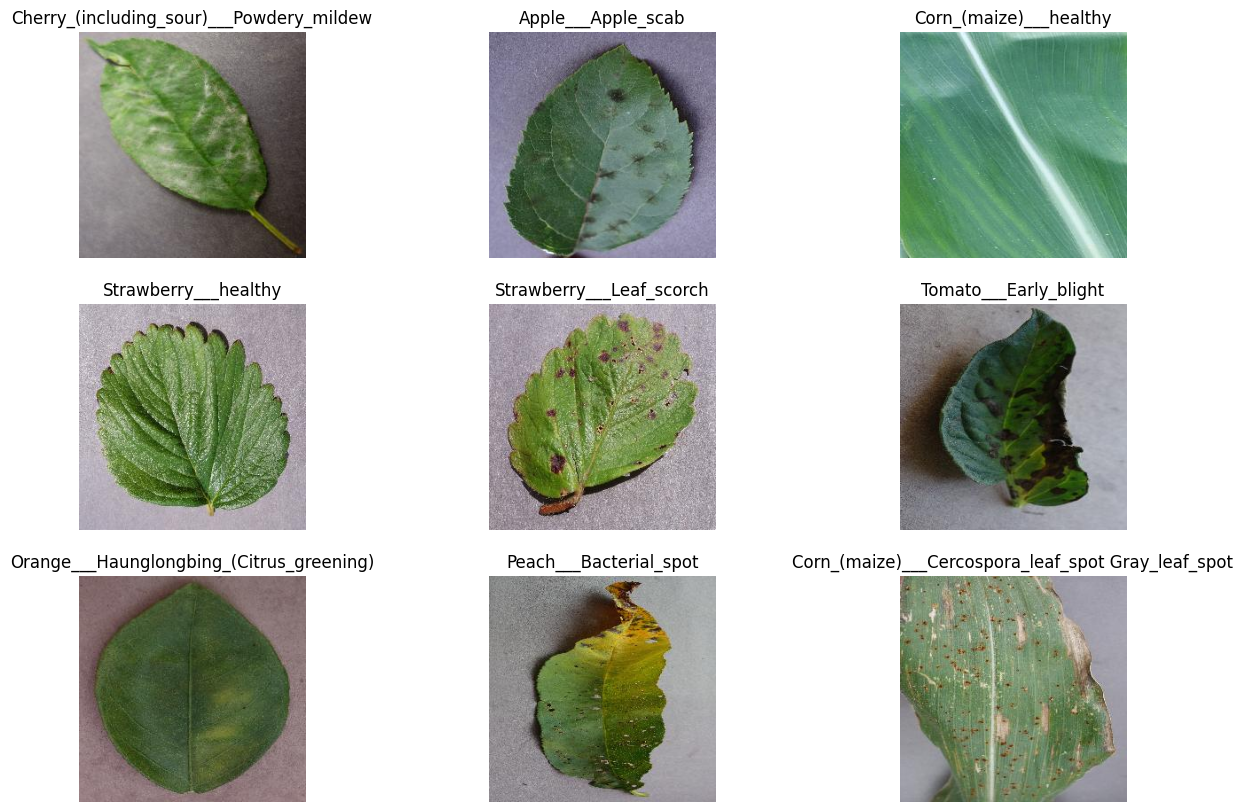

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

base_dir = "/content/plantvillage dataset/color"

classes = os.listdir(base_dir)

plt.figure(figsize=(15,10))

for i, cls in enumerate(classes[:9]):
    img_path = os.path.join(base_dir, cls, os.listdir(os.path.join(base_dir, cls))[0])
    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()